<a href="https://colab.research.google.com/github/ahm-gondal/ahm-gondal.github.io/blob/main/week3_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3, Part 1 — Dimensionality Reduction with PCA

**Objective:** Apply PCA to the Week 2 engineered steel-plant energy dataset to reduce the number of input features while keeping accuracy as close as possible to Week 2's best model (**Random Forest**, selected by cross-validation RMSE). The final trained pipeline (scaler + PCA + model) is saved with `joblib` for deployment in the FastAPI dashboard (Part 2).

**Leakage discipline:** the StandardScaler and PCA are fitted on the **training set only**, then used to transform both sets — fitting on the full dataset would leak test-set statistics into training.

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, io, zipfile, urllib.request

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

## 2. Load the Week 2 Engineered Dataset (same features, same encoding)

In [ ]:
ENG_PATH = 'data/steel_engineered.csv'

def rebuild_engineered():
    """Rebuild the Week 2 engineered dataset if the file is missing (identical logic to week2_eda.ipynb)."""
    csv_path = 'data/steel_industry_data.csv'
    if os.path.exists(csv_path):
        d = pd.read_csv(csv_path)
    else:
        url = 'https://archive.ics.uci.edu/static/public/851/steel+industry+energy+consumption.zip'
        raw = urllib.request.urlopen(url).read()
        zf = zipfile.ZipFile(io.BytesIO(raw))
        name = [n for n in zf.namelist() if n.lower().endswith('.csv')][0]
        d = pd.read_csv(zf.open(name))
        os.makedirs('data', exist_ok=True)
        d.to_csv(csv_path, index=False)
    d['date'] = pd.to_datetime(d['date'], dayfirst=True)
    d['Hour'] = d['date'].dt.hour
    d['Day_Num'] = d['date'].dt.dayofweek
    d['Day_Name'] = d['date'].dt.day_name()
    d['Month'] = d['date'].dt.month
    d['Is_Weekend'] = (d['Day_Num'] >= 5).astype(int)
    d['Power_Factor_Ratio'] = (d['Leading_Current_Power_Factor'] /
                               d['Lagging_Current_Power_Factor'].replace(0, np.nan))
    d['Power_Factor_Ratio'] = d['Power_Factor_Ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
    d['High_Load'] = (d['Usage_kWh'] > d['Usage_kWh'].quantile(0.75)).astype(int)
    d.to_csv(ENG_PATH, index=False)
    return d

df = pd.read_csv(ENG_PATH, parse_dates=['date']) if os.path.exists(ENG_PATH) else rebuild_engineered()
print('Engineered dataset:', df.shape)

Engineered dataset: (35040, 18)


In [ ]:
# Identical preprocessing to Week 2: drop date + leakage/duplicate columns, one-hot encode
drop_cols = [c for c in ['date', 'High_Load', 'CO2(tCO2)', 'WeekStatus', 'Day_Name'] if c in df.columns]
model_df = df.drop(columns=drop_cols)
cat_cols = [c for c in ['Load_Type', 'Day_of_week'] if c in model_df.columns]
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

y = model_df['Usage_kWh']
X = model_df.drop(columns=['Usage_kWh'])
FEATURES = list(X.columns)
print(f'{X.shape[1]} features:', FEATURES)

18 features: ['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Hour', 'Day_Num', 'Month', 'Is_Weekend', 'Power_Factor_Ratio', 'Load_Type_Maximum_Load', 'Load_Type_Medium_Load', 'Day_of_week_Monday', 'Day_of_week_Saturday', 'Day_of_week_Sunday', 'Day_of_week_Thursday', 'Day_of_week_Tuesday', 'Day_of_week_Wednesday']


## 3. Same Train/Test Split as Week 2 — Scaler and PCA Fitted on Training Data Only

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}   Test: {X_test.shape}')

# Fit ONLY on the training set (no leakage), transform both sets
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# PCA with n_components = total number of features, to see ALL variance explained
pca_full = PCA(n_components=X_train.shape[1]).fit(X_train_s)
X_train_p = pca_full.transform(X_train_s)
X_test_p = pca_full.transform(X_test_s)
print('PCA fitted with', pca_full.n_components_, 'components')

Train: (28032, 18)   Test: (7008, 18)
PCA fitted with 18 components


## 4. Scree Plot — Explained Variance Ratio per Component

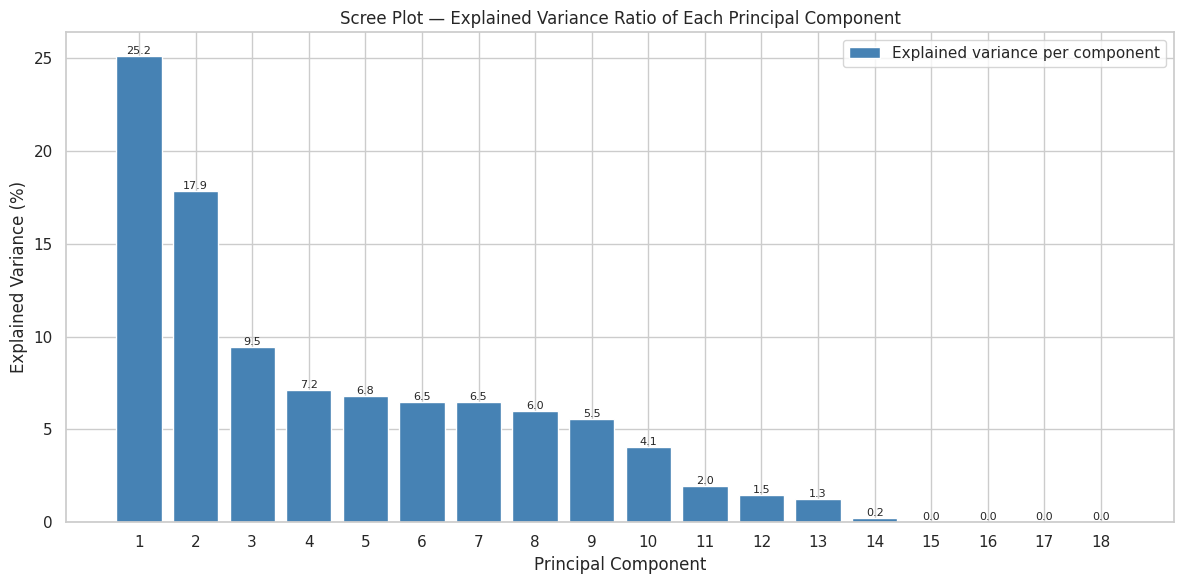

In [ ]:
evr = pca_full.explained_variance_ratio_
comp_ids = np.arange(1, len(evr) + 1)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(comp_ids, evr * 100, color='steelblue', label='Explained variance per component')
ax.bar_label(bars, fmt='%.1f', fontsize=8)
ax.set_title('Scree Plot — Explained Variance Ratio of Each Principal Component')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_xticks(comp_ids)
ax.legend()
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Cumulative Explained Variance — How Many Components for 95%?

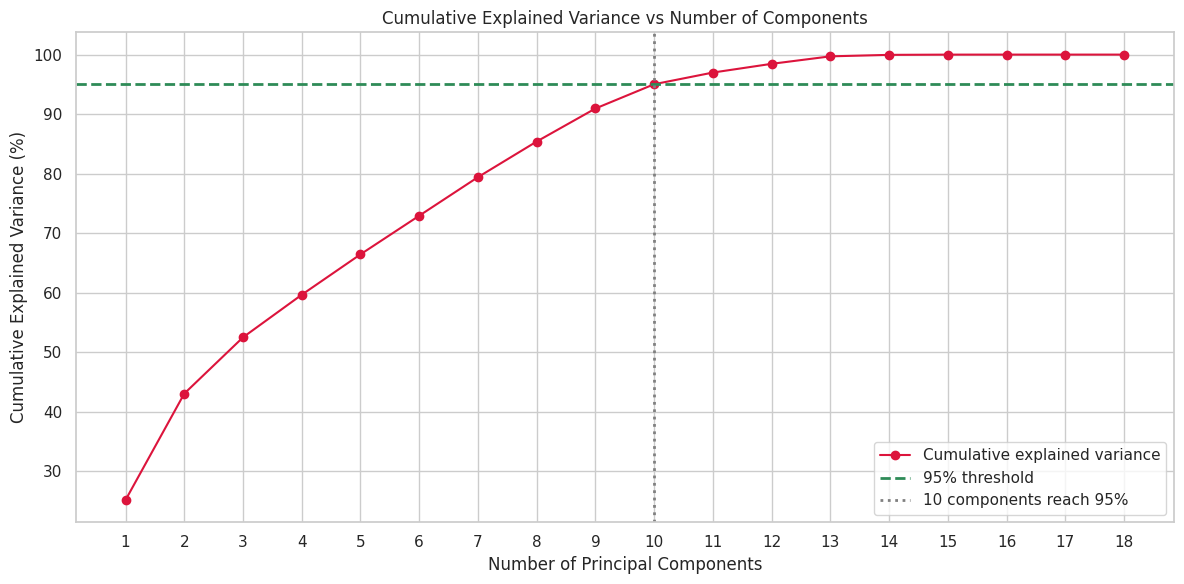

Components needed to reach 95% of variance: 10
Variance captured by first 3 components: 52.5%
Variance captured by 10 components: 95.0%


In [ ]:
cum = np.cumsum(evr)
n95 = int(np.argmax(cum >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(comp_ids, cum * 100, marker='o', color='crimson', label='Cumulative explained variance')
ax.axhline(95, color='seagreen', linestyle='--', linewidth=2, label='95% threshold')
ax.axvline(n95, color='gray', linestyle=':', linewidth=2, label=f'{n95} components reach 95%')
ax.set_title('Cumulative Explained Variance vs Number of Components')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_xticks(comp_ids)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('cumulative_variance.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'Components needed to reach 95% of variance: {n95}')
print(f'Variance captured by first 3 components: {cum[2]:.1%}')
print(f'Variance captured by {n95} components: {cum[n95-1]:.1%}')

## 6. Retrain the Best Week 2 Model (Random Forest) on Three Feature Versions

1. **Original** — all features, no PCA (Week 2 baseline, retrained identically)
2. **PCA-3** — only the first 3 principal components
3. **PCA-95%** — the components that capture 95% of variance

In [ ]:
def evaluate(model, Xtr, Xte):
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return rmse, r2

rf = lambda: RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

results = {}
results['Original (18 features)'] = evaluate(rf(), X_train, X_test)
results['PCA - 3 components'] = evaluate(rf(), X_train_p[:, :3], X_test_p[:, :3])
results[f'PCA - {n95} components (95%)'] = evaluate(rf(), X_train_p[:, :n95], X_test_p[:, :n95])

comp_df = pd.DataFrame(results, index=['RMSE', 'R2']).T
for name, (rmse, r2) in results.items():
    print(f'{name:28s} | RMSE: {rmse:7.3f} | R\u00b2: {r2:.4f}')
comp_df.round(4)

Original (18 features)       | RMSE:   0.877 | R²: 0.9993
PCA - 3 components           | RMSE:  11.026 | R²: 0.8930
PCA - 10 components (95%)    | RMSE:   4.605 | R²: 0.9813


,RMSE,R2
Original (18 features),0.8769,0.9993
PCA - 3 components,11.0262,0.8930
PCA - 10 components (95%),4.6055,0.9813


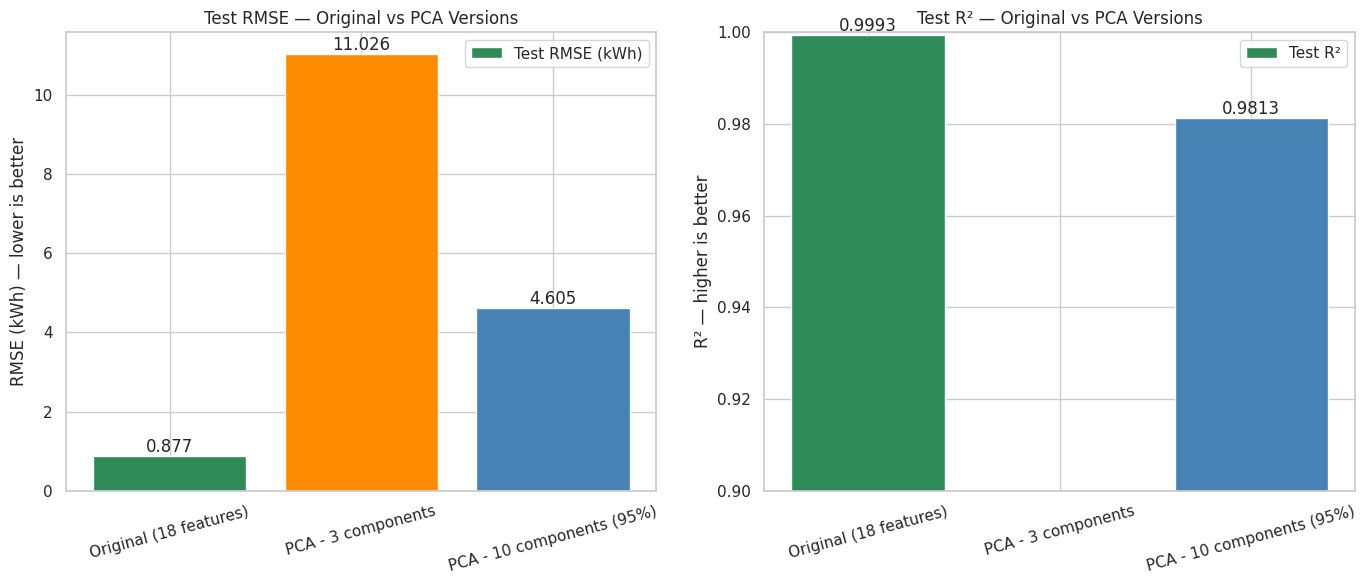

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['seagreen', 'darkorange', 'steelblue']

b0 = axes[0].bar(comp_df.index, comp_df['RMSE'], color=colors, label='Test RMSE (kWh)')
axes[0].bar_label(b0, fmt='%.3f')
axes[0].set_title('Test RMSE — Original vs PCA Versions')
axes[0].set_ylabel('RMSE (kWh) — lower is better')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

b1 = axes[1].bar(comp_df.index, comp_df['R2'], color=colors, label='Test R\u00b2')
axes[1].bar_label(b1, fmt='%.4f')
axes[1].set_title('Test R\u00b2 — Original vs PCA Versions')
axes[1].set_ylabel('R\u00b2 — higher is better')
axes[1].set_ylim(0.9, 1.0)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Loading Heatmap — Which Original Features Drive the First 3 Components?

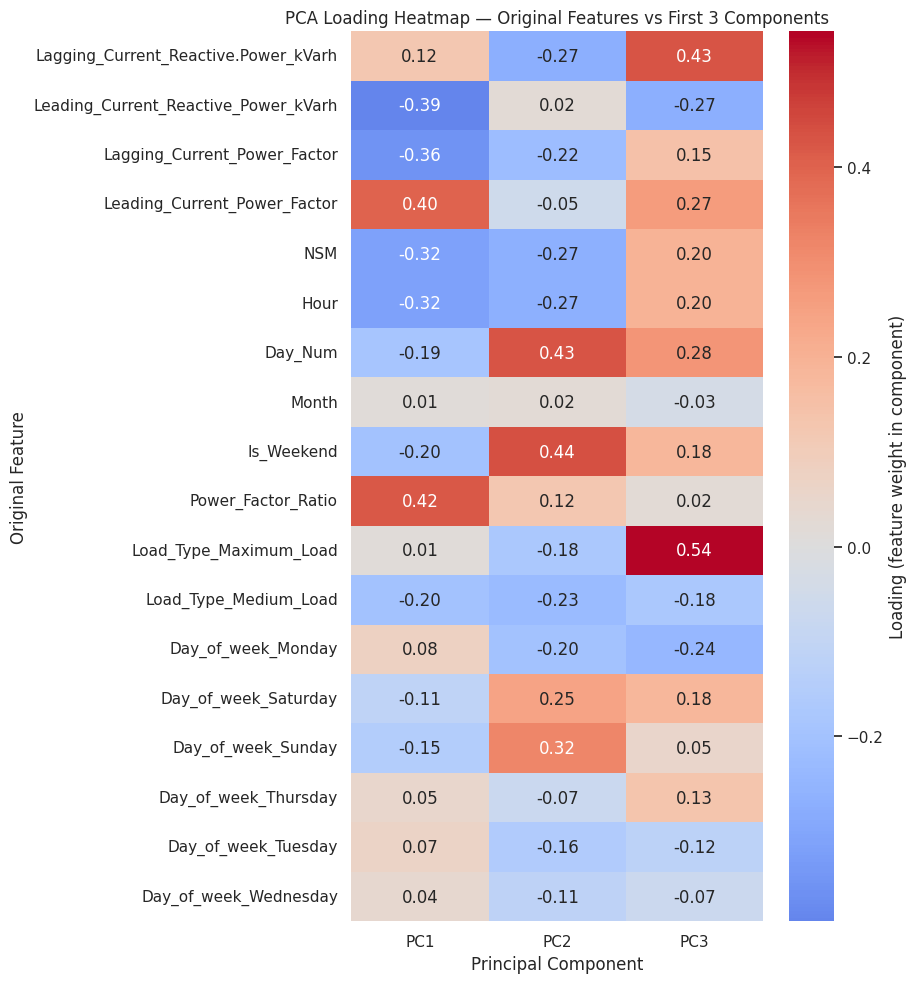

PC1 is driven most by: Power_Factor_Ratio (+0.42), Leading_Current_Power_Factor (+0.40), Leading_Current_Reactive_Power_kVarh (-0.39)
PC2 is driven most by: Is_Weekend (+0.44), Day_Num (+0.43), Day_of_week_Sunday (+0.32)
PC3 is driven most by: Load_Type_Maximum_Load (+0.54), Lagging_Current_Reactive.Power_kVarh (+0.43), Day_Num (+0.28)


In [ ]:
loadings = pd.DataFrame(pca_full.components_[:3].T,
                        index=FEATURES,
                        columns=['PC1', 'PC2', 'PC3'])

fig, ax = plt.subplots(figsize=(9, 10))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'label': 'Loading (feature weight in component)'})
ax.set_title('PCA Loading Heatmap — Original Features vs First 3 Components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Original Feature')
plt.tight_layout()
plt.savefig('loading_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(3)
    print(f'{pc} is driven most by: ' + ', '.join(f'{f} ({loadings[pc][f]:+.2f})' for f in top.index))

## 8. Save the Deployment Pipeline (scaler + PCA + model) with joblib

The full pipeline is saved as one object so preprocessing is never lost at prediction time. For deployment we use a compact Random Forest (fewer, slightly regularised trees) so the file stays small enough for the web app — its accuracy is verified below.

In [ ]:
deploy_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n95)),
    ('model', RandomForestRegressor(n_estimators=30, min_samples_leaf=4,
                                    random_state=42, n_jobs=-1)),
])
deploy_pipe.fit(X_train, y_train)
pred = deploy_pipe.predict(X_test)
print(f'Deployment pipeline  | RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.3f} | R\u00b2: {r2_score(y_test, pred):.4f}')

joblib.dump({'pipeline': deploy_pipe, 'features': FEATURES}, 'model.joblib', compress=3)
size_mb = os.path.getsize('model.joblib') / 1e6
print(f'Saved model.joblib ({size_mb:.1f} MB) — contains the fitted pipeline AND the feature-name list')

Deployment pipeline  | RMSE: 5.069 | R²: 0.9774
Saved model.joblib (5.0 MB) — contains the fitted pipeline AND the feature-name list


## 9. Export the Week 2 EDA Charts for the FastAPI Dashboard (Part 2)

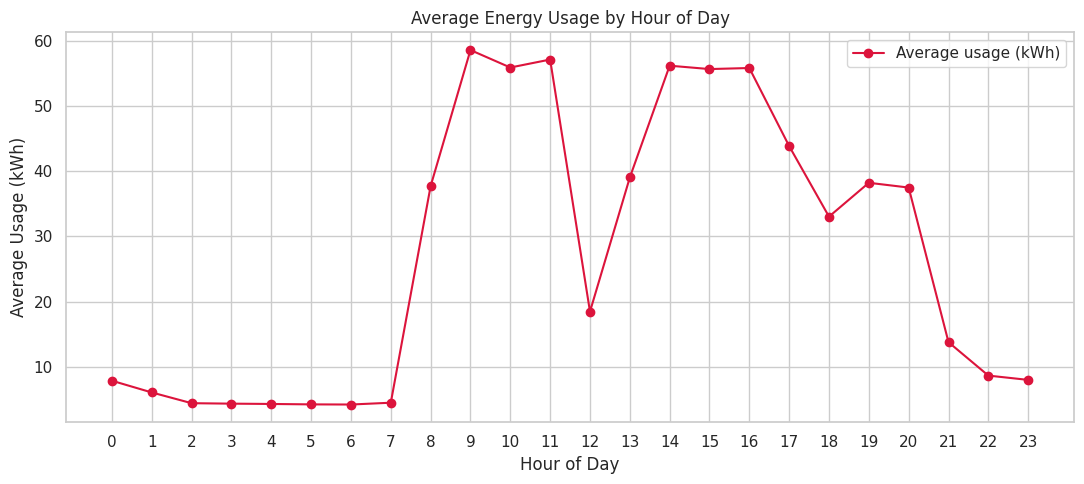

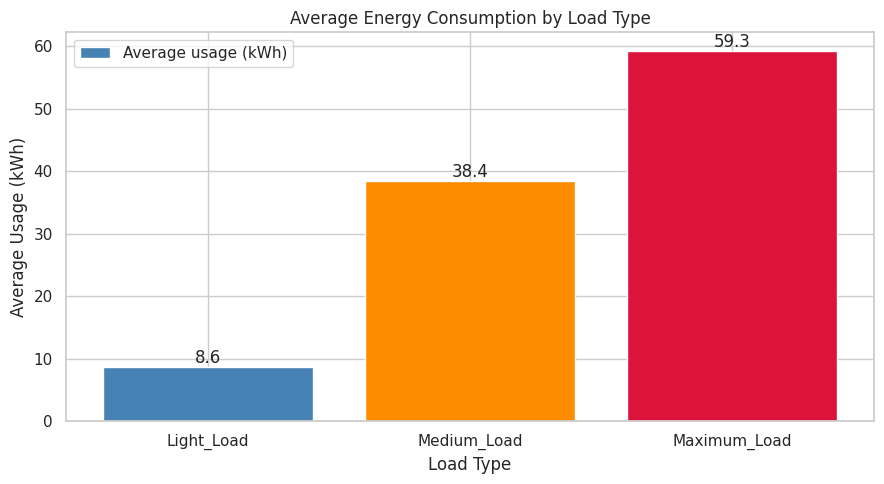

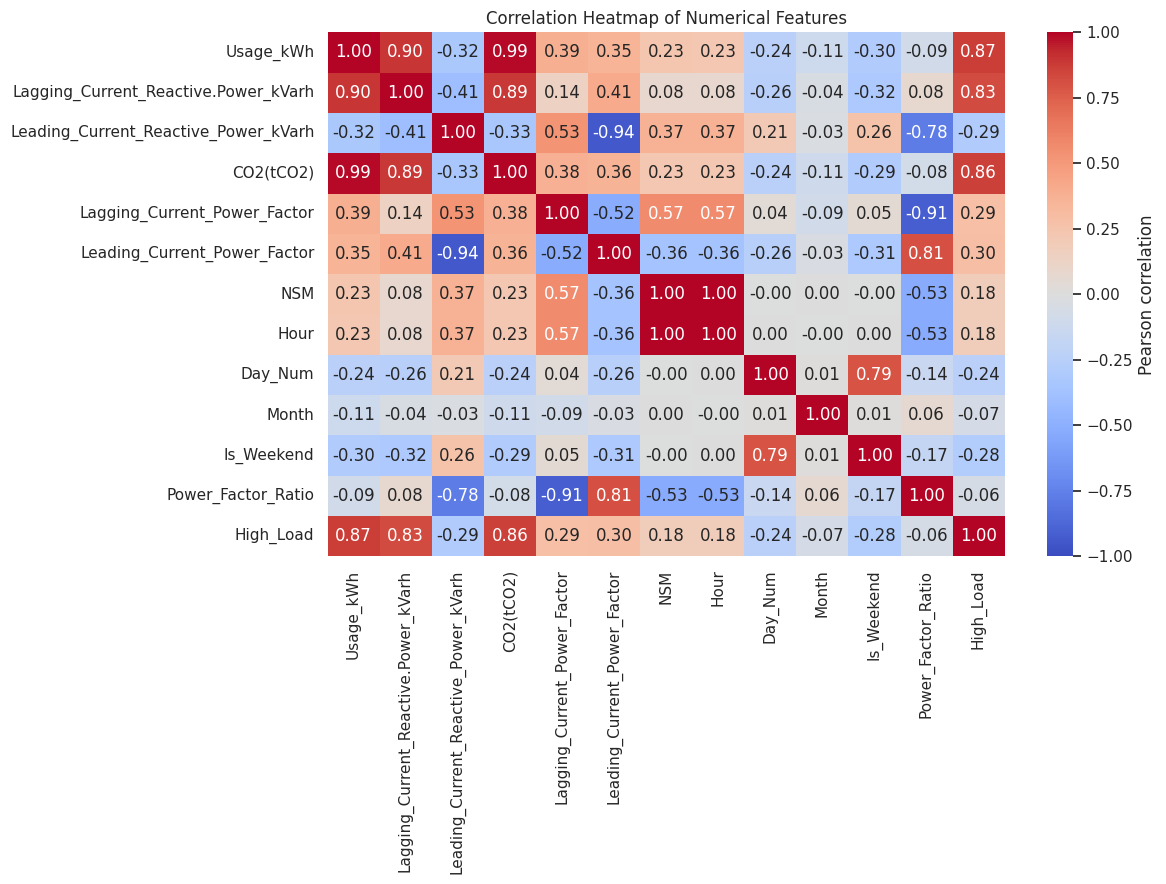

Saved: energy_by_hour.png, energy_by_load_type.png, correlation_heatmap.png


In [ ]:
# Chart 1: average energy by hour
hourly = df.groupby('Hour')['Usage_kWh'].mean()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hourly.index, hourly.values, marker='o', color='crimson', label='Average usage (kWh)')
ax.set_title('Average Energy Usage by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Usage (kWh)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout(); plt.savefig('energy_by_hour.png', dpi=110, bbox_inches='tight'); plt.show()

# Chart 2: average energy by load type
avg_load = df.groupby('Load_Type')['Usage_kWh'].mean().reindex(['Light_Load', 'Medium_Load', 'Maximum_Load'])
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(avg_load.index, avg_load.values, color=['steelblue', 'darkorange', 'crimson'], label='Average usage (kWh)')
ax.bar_label(bars, fmt='%.1f')
ax.set_title('Average Energy Consumption by Load Type')
ax.set_xlabel('Load Type')
ax.set_ylabel('Average Usage (kWh)')
ax.legend()
plt.tight_layout(); plt.savefig('energy_by_load_type.png', dpi=110, bbox_inches='tight'); plt.show()

# Chart 3: correlation heatmap of numeric features
corr = df.select_dtypes(include=[np.number]).corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Pearson correlation'})
ax.set_title('Correlation Heatmap of Numerical Features')
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=110, bbox_inches='tight'); plt.show()
print('Saved: energy_by_hour.png, energy_by_load_type.png, correlation_heatmap.png')

In [ ]:
# Bundle everything needed for the FastAPI app into one zip (easy download)
import zipfile as zfmod
with zfmod.ZipFile('week3_assets.zip', 'w') as z:
    for f in ['model.joblib', 'energy_by_hour.png', 'energy_by_load_type.png',
              'correlation_heatmap.png', 'scree_plot.png', 'cumulative_variance.png',
              'loading_heatmap.png']:
        z.write(f)
print('week3_assets.zip created:', round(os.path.getsize('week3_assets.zip')/1e6, 1), 'MB')

week3_assets.zip created: 5.6 MB


## 10. Dimensionality Reduction Report

**Did accuracy drop significantly?** Yes - and the size of the drop depends on how much variance we keep. With only **3 components** (52.5% of variance) RMSE explodes from **0.877 to 11.03 kWh** (R2 0.9993 to 0.8930) - too much information is thrown away. With **10 components** (95% of variance) the model recovers to **RMSE 4.61, R2 0.9813** - excellent in absolute terms, but still about 5x the error of the original 18-feature model. Random Forests split on individual raw features, so PCA's rotation of the feature space genuinely costs them accuracy; the original model remains the accuracy champion.

**How many features can safely be removed?** 8 of the 18 dimensions can be removed (18 to 10 components) while retaining 95% of variance and R2 = 0.98. The loading heatmap shows why: the features overlap heavily - PC1 bundles the power-factor / reactive-power group, PC2 the weekend / day-of-week calendar group, and PC3 production intensity (Maximum load + lagging reactive power). If ~0.98 R2 meets the business need, 10 components is safe; if the 0.999 baseline is required, keep all original features.

**Would I recommend PCA for a memory-constrained device?** Yes, with a documented trade-off. PCA cuts input dimensionality by ~45%, shrinking the forest and inference RAM, while the added cost of the scaler + PCA transform is trivial (an 18x10 matrix multiply). The deployed pipeline (scaler + 10-component PCA + compact 30-tree forest: RMSE 5.07, R2 0.977) compresses to a **5 MB** file - versus hundreds of MB for a full uncompressed forest. For an edge device I accept the ~2% R2 sacrifice; on a normal server I would deploy the original-feature model instead.

**Leakage note.** The scaler and PCA were fitted on the training set only and reused to transform the test set - fitting them on the full dataset would have leaked test-set statistics into the transformation and produced optimistic results.